## 1. Load & Inspect

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
vinyl_df_raw = pd.read_csv("data/vinyl_dataset.csv")
vinyl_df = vinyl_df_raw

vinyl_df.head(10)

,listing_id,artist_name,album_name,genre,release_year,pressing_country,pressing_variant,is_limited_edition,media_condition,sleeve_condition,...,artist_popularity_score,album_acclaim_score,days_on_market,seller_feedback_count,seller_feedback_pct,shipping_included,listing_type,listing_year,recent_comp_median_price,price
0,1,Midnight Oil,Blue Sky Mining,Rock,1967,uk,Limited Colored Vinyl,1,Very Good Plus,Fair,...,29.3,35.6,57.0,2612,97.8%,False,Auction,2019,46.22,$59.95
1,2,Jane's Addiction,Ritual de lo Habitual,Alternative,1968,France,Standard Reissue,No,Fair,Very Good Plus,...,24.1,19.5,54.0,4793,93.1%,True,Fixed Price,2019,33.51,$32.20
2,3,Wu-Tang Clan,Enter the Wu-Tang (36 Chambers),Hip-Hop,2004,Brazil,Original 1st Press,No,Very Good,Good,...,68.0,12.7,5.0,1555,92.5%,No,Auction,2019,65.57,$61.08
3,4,Sufjan Stevens,Michigan,Folk,2020,Netherlands,Original 1st Press,0,Mint,Very Good Plus,...,47.0,34.9,28.0,2283,94.3%,No,Fixed Price,2025,53.03,$66.52
4,5,Michael Jackson,Thriller,Pop,1984,BRAZIL,Standard Reissue,False,Mint,Mint,...,91.7,64.0,5.0,248,97.0%,Yes,Auction,2020,63.75,$100.75
5,6,Vampire Weekend,Modern Vampires of the City,Alternative,1989,japan,Standard Reissue,False,Very Good,Mint,...,69.0,24.6,16.0,3854,99.8%,No,Fixed Price,2017,49.18,$64.61
6,7,David Bowie,Heroes,Rock,1961,Netherlands,Original 1st Press,No,Very Good,Mint,...,89.0,5.0,0.0,2391,100.0%,No,Auction,2020,66.74,$86.58
7,8,The Rolling Stones,Tattoo You,Rock,2016,france,Test Pressing,True,Very Good Plus,Near Mint,...,91.7,39.3,19.0,1740,97.1%,no,Fixed Price,2020,100.53,$124.70
8,9,Marvin Gaye,Let's Get It On,Soul,1967,UK,Limited Colored Vinyl,Yes,Near Mint,Good Plus,...,94.9,74.6,40.0,4780,99.3%,1,Fixed Price,2023,80.44,$116.12
9,10,Bjork,Vespertine,Electronic,2004,Germany,Standard Reissue,0,Near Mint,Good,...,67.1,18.9,22.0,3911,98.0%,False,Fixed Price,2021,54.06,$56.29


In [43]:
vinyl_df.shape

(5015, 25)

In [44]:
vinyl_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   listing_id                5015 non-null   int64  
 1   artist_name               5015 non-null   str    
 2   album_name                5015 non-null   str    
 3   genre                     5015 non-null   str    
 4   release_year              5015 non-null   int64  
 5   pressing_country          4864 non-null   str    
 6   pressing_variant          5015 non-null   str    
 7   is_limited_edition        5015 non-null   str    
 8   media_condition           5015 non-null   str    
 9   sleeve_condition          4765 non-null   str    
 10  weight_grams              4865 non-null   str    
 11  copies_pressed            5015 non-null   str    
 12  community_have            5015 non-null   int64  
 13  community_want            4913 non-null   float64
 14  want_have_ratio    

## 2. Clean
Fix dtypes, drop irrelevant columns, handle duplicates/missing data.

In [45]:
#listing_id is irrelevant for modeling

vinyl_df = vinyl_df.drop(columns=["listing_id"])

In [46]:
#drop na from price column since it's going to be our target

vinyl_df = vinyl_df.dropna(subset=["price"])

In [47]:
vinyl_df.duplicated().sum()

np.int64(0)

In [48]:
target_cols = [
    "is_limited_edition",
    "media_condition",
    "sleeve_condition",
    "shipping_included",
]


for col in target_cols:
    print(f"{col} ({vinyl_df[col].nunique()} unique): ")
    print(list(vinyl_df[col].unique()))
    print()


is_limited_edition (8 unique): 
['1', 'No', '0', 'False', 'True', 'Yes', 'no', 'yes']

media_condition (16 unique): 
['Very Good Plus', 'Fair', 'Very Good', 'Mint', 'Near Mint', '  Very Good ', 'Good Plus', 'Good', '  Near Mint ', 'Poor', '  Good Plus ', '  Fair ', '  Very Good Plus ', '  Mint ', '  Good ', '  Poor ']

sleeve_condition (8 unique): 
['Fair', 'Very Good Plus', 'Good', 'Mint', 'Near Mint', 'Good Plus', nan, 'Very Good', 'Poor']

shipping_included (8 unique): 
['False', 'True', 'No', 'Yes', 'no', '1', '0', 'yes']



In [49]:
boolean_map = {
    "1": True, "True": True, "Yes": True, "yes": True,
    "0": False, "No": False, "False": False, "no": False
}

condition_map = {
    "Good": 1,
    "Very Good": 2,
    "Very Good Plus": 3,
    "Near Mint": 4,
    "Mint": 5,
}

vinyl_df["is_limited_edition"] = vinyl_df["is_limited_edition"].map(boolean_map).astype(bool)
vinyl_df["shipping_included"] = vinyl_df["shipping_included"].map(boolean_map).astype(bool)

vinyl_df['media_condition'] = vinyl_df['media_condition'].str.strip()
vinyl_df['sleeve_condition'] = vinyl_df['sleeve_condition'].str.strip()

vinyl_df["media_condition"] = vinyl_df["media_condition"].map(condition_map)
vinyl_df["sleeve_condition"] = vinyl_df["sleeve_condition"].map(condition_map)

In [50]:
#fix dates

vinyl_df["age"] = vinyl_df["listing_year"] - vinyl_df["release_year"]

#successfully derived the age of the record, we do not need these columns anymore
vinyl_df = vinyl_df.drop(columns=["listing_year", "release_year"])

In [51]:
#fix pricing

In [52]:
vinyl_df["seller_feedback_pct"].head()

0    97.8%
1    93.1%
2    92.5%
3    94.3%
4    97.0%
Name: seller_feedback_pct, dtype: str

In [53]:
#convert "seller_feedback_pct" into numeric dtype

vinyl_df["seller_feedback_pct"] = vinyl_df["seller_feedback_pct"].str.strip().str.replace("%", "")
vinyl_df["seller_feedback_pct"] = pd.to_numeric(vinyl_df["seller_feedback_pct"], errors="coerce") / 100

vinyl_df["seller_feedback_pct"].head()

0    0.978
1    0.931
2    0.925
3    0.943
4    0.970
Name: seller_feedback_pct, dtype: float64

In [54]:
vinyl_df["seller_reputation"] = vinyl_df["seller_feedback_count"] * vinyl_df["seller_feedback_pct"]

#saf to drop feedback count and pct
vinyl_df = vinyl_df.drop(columns=["seller_feedback_count", "seller_feedback_pct"])

In [55]:
vinyl_df["weight_grams"].sample(10, random_state=42)

4874    180.0
1025     140g
3545    180.0
3821     120g
4394     180g
3422     140g
2417    200.0
1095     120g
4459     140g
705     140.0
Name: weight_grams, dtype: str

In [56]:
vinyl_df["weight_grams"] = pd.to_numeric(vinyl_df["weight_grams"].str.strip().str.replace("g", ""))

In [57]:
vinyl_df["pressing_variant"].sample(10, random_state=42)

4874            Test Pressing
1025               Promo Copy
3545         Standard Reissue
3821    Limited Colored Vinyl
4394         Standard Reissue
3422         Standard Reissue
2417    Limited Colored Vinyl
1095      Anniversary Edition
4459    Limited Colored Vinyl
705     Limited Colored Vinyl
Name: pressing_variant, dtype: str

In [58]:
vinyl_df["pressing_variant"].unique()

<StringArray>
['Limited Colored Vinyl',      'Standard Reissue',    'Original 1st Press',
         'Test Pressing',   'Anniversary Edition',            'Promo Copy']
Length: 6, dtype: str

In [59]:
vinyl_df.dtypes

artist_name                     str
album_name                      str
genre                           str
pressing_country                str
pressing_variant                str
is_limited_edition             bool
media_condition             float64
sleeve_condition            float64
weight_grams                float64
copies_pressed                  str
community_have                int64
community_want              float64
want_have_ratio             float64
artist_popularity_score     float64
album_acclaim_score         float64
days_on_market              float64
shipping_included              bool
listing_type                    str
recent_comp_median_price    float64
price                           str
age                           int64
seller_reputation           float64
dtype: object

In [60]:
vinyl_df["price"].sample(15, random_state=42)

4874    $110.63
1025     $93.89
3545     $69.66
3821     $84.59
4394     $70.53
3422     $54.33
2417     $78.76
1095     $81.48
4459    $100.77
705      $78.13
2374     $71.37
530     $107.28
800     $106.87
4524     $71.24
1456     $98.76
Name: price, dtype: str

In [61]:
vinyl_df["price"] = pd.to_numeric(vinyl_df["price"].str.strip().str.replace("$", ""))

In [62]:
vinyl_df["price"].sample(15, random_state=42)

4874    110.63
1025     93.89
3545     69.66
3821     84.59
4394     70.53
3422     54.33
2417     78.76
1095     81.48
4459    100.77
705      78.13
2374     71.37
530     107.28
800     106.87
4524     71.24
1456     98.76
Name: price, dtype: float64

In [63]:
vinyl_df.dtypes

artist_name                     str
album_name                      str
genre                           str
pressing_country                str
pressing_variant                str
is_limited_edition             bool
media_condition             float64
sleeve_condition            float64
weight_grams                float64
copies_pressed                  str
community_have                int64
community_want              float64
want_have_ratio             float64
artist_popularity_score     float64
album_acclaim_score         float64
days_on_market              float64
shipping_included              bool
listing_type                    str
recent_comp_median_price    float64
price                       float64
age                           int64
seller_reputation           float64
dtype: object

In [64]:
vinyl_df = vinyl_df.drop(columns=["artist_name", "album_name"])

vinyl_df.sample(10, random_state=42)

,genre,pressing_country,pressing_variant,is_limited_edition,media_condition,sleeve_condition,weight_grams,copies_pressed,community_have,community_want,want_have_ratio,artist_popularity_score,album_acclaim_score,days_on_market,shipping_included,listing_type,recent_comp_median_price,price,age,seller_reputation
4874,R&B,Brazil,Test Pressing,True,2.0,3.0,180.0,"14,374",125,113.0,0.904,82.8,63.1,2.0,False,Auction,91.93,110.63,55,1227.000
1025,R&B,GERMANY,Promo Copy,False,4.0,5.0,140.0,"39,640",720,1717.0,2.385,63.8,16.7,16.0,False,Fixed Price,58.18,93.89,3,3482.100
3545,Rock,US,Standard Reissue,False,4.0,NaN,180.0,"24,581",164,294.0,1.793,95.6,36.9,40.0,True,Fixed Price,63.53,69.66,4,3611.888
3821,R&B,JAPAN,Limited Colored Vinyl,True,3.0,2.0,120.0,"38,167",708,195.0,0.275,77.2,67.1,8.0,True,Fixed Price,66.56,84.59,22,8.361
4394,Folk,France,Standard Reissue,False,2.0,2.0,180.0,"14,908",62,89.0,1.435,71.9,44.6,8.0,True,Fixed Price,64.03,70.53,44,2642.388
3422,Hip-Hop,Brazil,Standard Reissue,False,2.0,1.0,140.0,"48,793",1084,2420.0,2.232,70.3,14.9,10.0,True,Fixed Price,46.43,54.33,35,1776.940
2417,Soul,Canada,Limited Colored Vinyl,True,NaN,4.0,200.0,"20,101",392,507.0,1.293,67.1,30.6,31.0,True,Fixed Price,67.56,78.76,62,2832.312
1095,Rock,Japan,Anniversary Edition,True,3.0,2.0,120.0,"32,123",550,903.0,1.642,90.5,37.7,25.0,False,Fixed Price,62.65,81.48,46,1537.515
4459,Rock,US,Limited Colored Vinyl,True,5.0,NaN,140.0,"12,873",737,1787.0,2.425,91.6,70.3,3.0,True,Fixed Price,81.24,100.77,32,2367.000
705,Alternative,us,Limited Colored Vinyl,True,4.0,2.0,140.0,"22,289",127,62.0,0.488,55.8,33.1,14.0,False,Fixed Price,56.96,78.13,35,1431.672


In [65]:
vinyl_df["pressing_country"] = vinyl_df["pressing_country"].str.lower()
vinyl_df["pressing_country"].sample(10, random_state=42)

4874     brazil
1025    germany
3545         us
3821      japan
4394     france
3422     brazil
2417     canada
1095      japan
4459         us
705          us
Name: pressing_country, dtype: str

In [66]:
vinyl_df = vinyl_df.drop(columns=["community_have", "community_want"])

## 3. EDA
Check target distribution and how features relate to price before modeling.

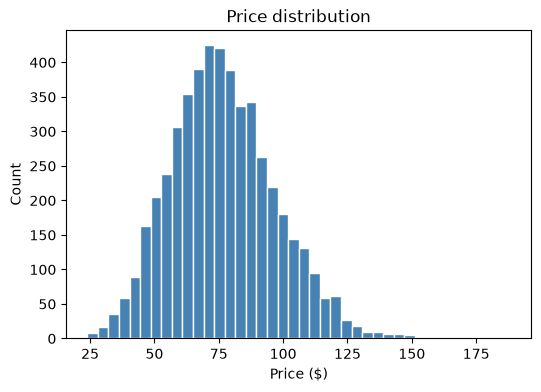

In [67]:
plt.figure(figsize=(6,4))
plt.hist(vinyl_df["price"].dropna(), bins=40, color='steelblue', edgecolor='white')
plt.title("Price distribution")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

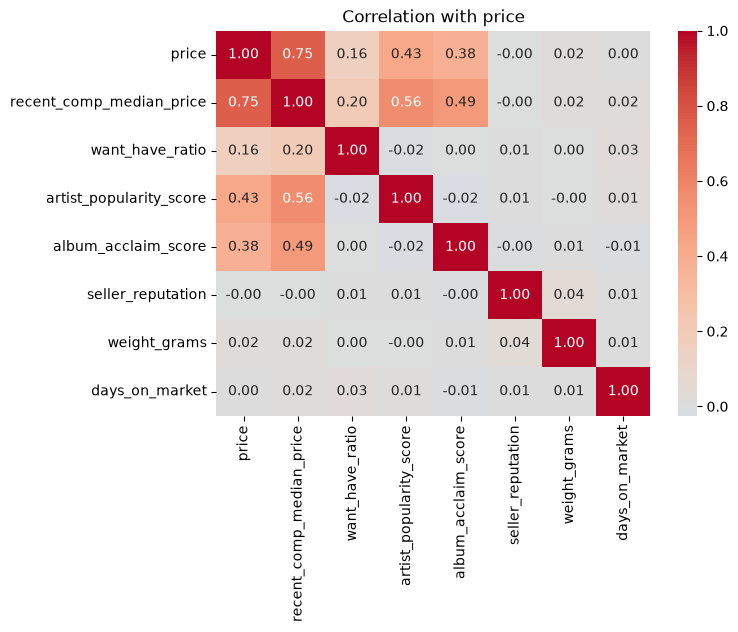

In [68]:
num_cols = ["price","recent_comp_median_price","want_have_ratio","artist_popularity_score",
            "album_acclaim_score","seller_reputation","weight_grams","days_on_market"]
corr = vinyl_df[num_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation with price")
plt.show()

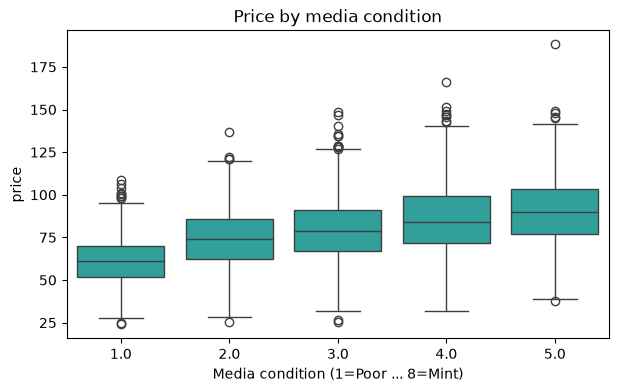

In [69]:
plt.figure(figsize=(7,4))
sns.boxplot(data=vinyl_df, x="media_condition", y="price", color='lightseagreen')
plt.title("Price by media condition")
plt.xlabel("Media condition (1=Poor ... 8=Mint)")
plt.show()

In [70]:
vinyl_df["price"].isna().sum()

np.int64(0)

### data split

In [71]:
from sklearn.model_selection import train_test_split

numeric_feats = [
    "recent_comp_median_price",
    "seller_reputation",
    "weight_grams",
    "want_have_ratio",
    "artist_popularity_score",
    "album_acclaim_score",
    "days_on_market",
    "age",
    "media_condition",
    "sleeve_condition",
    "is_limited_edition",
    "shipping_included" 
]

categorical_feats = [
    "genre", "pressing_country", "listing_type", "pressing_variant"
]

X = vinyl_df[numeric_feats + categorical_feats]
y = vinyl_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### build pipline

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

num_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        (
            "encoder", 
            OneHotEncoder(
                drop="if_binary", handle_unknown="ignore", sparse_output=False
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numeric_feats),
        ("cat", cat_transformer, categorical_feats)
    ],
    remainder="passthrough"
)


reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [73]:
reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['recent_comp_median_price','seller_reputation','weight_grams',..., 'pressing_country','listing_type','pressing_variant']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be au

In [74]:
from sklearn.metrics import mean_absolute_error

predictions = reg_pipeline.predict(X_test)

r2_score = reg_pipeline.score(X_test, y_test)
mae = mean_absolute_error(y_test, predictions)

print(f"r2 score: {r2_score: .4f}")
print(f"MAE: {mae: .2f}")

r2 score:  0.7095
MAE:  8.24


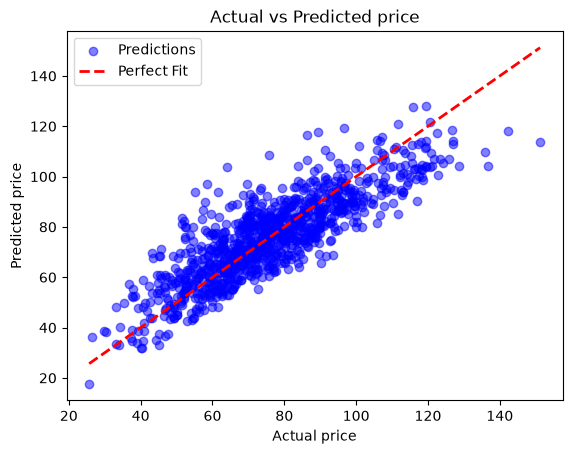

In [75]:
plt.scatter(y_test, predictions, alpha=0.5, color='blue', label='Predictions')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')

plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs Predicted price')
plt.legend()
plt.show()